In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [138]:
housing = pd.read_csv('Housing.csv')
housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


# Understanding the Data

In [139]:
housing.sample(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
120,5950000,6540,3,1,1,yes,yes,yes,no,no,2,yes,furnished
30,8400000,7475,3,2,4,yes,no,no,no,yes,2,no,unfurnished
209,4900000,6720,3,1,1,yes,no,no,no,no,0,no,unfurnished
251,4515000,3450,3,1,2,yes,no,yes,no,no,1,no,semi-furnished
189,5040000,3540,2,1,1,no,yes,yes,no,no,0,no,semi-furnished


In [140]:
housing.shape

(545, 13)

In [141]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [142]:
housing.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [143]:
housing.duplicated().sum()

np.int64(0)

# Feature Engineering

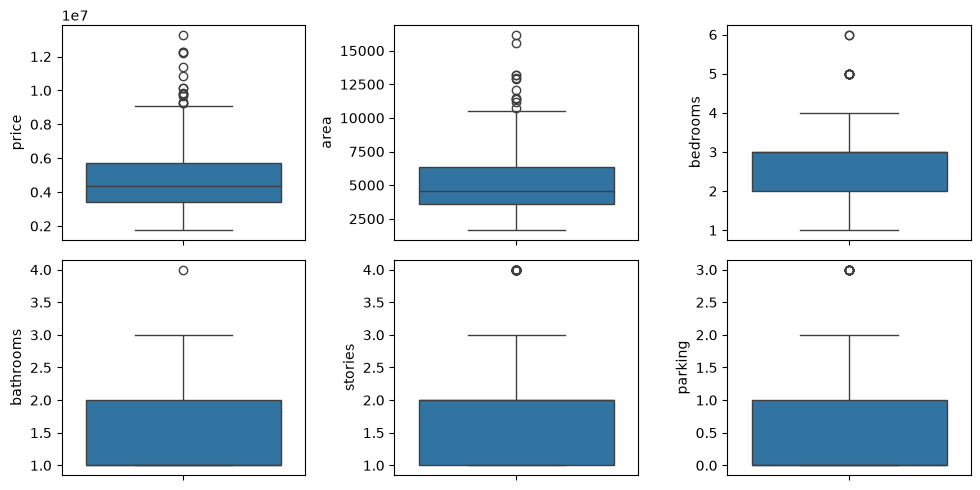

In [145]:
# outlier analysis
fig, axs = plt.subplots(2,3, figsize=(10,5))
plt1 = sns.boxplot(housing['price'], ax = axs[0,0])
plt2 = sns.boxplot(housing['area'], ax = axs[0,1])
plt3 = sns.boxplot(housing['bedrooms'], ax = axs[0,2])
plt1 = sns.boxplot(housing['bathrooms'], ax = axs[1,0])
plt2 = sns.boxplot(housing['stories'], ax = axs[1,1])
plt3 = sns.boxplot(housing['parking'], ax = axs[1,2])

plt.tight_layout()

In [146]:
# we have significant number of outliers in price and area column. so we will remove these outliers 

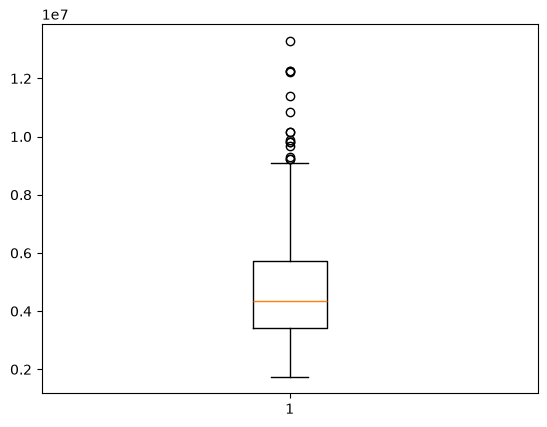

In [147]:
# price outlier treatment
plt.boxplot(housing.price)
Q1 = housing.price.quantile(0.25)
Q3 = housing.price.quantile(0.75)

iqr = Q3-Q1

housing = housing[(housing.price >= Q1 - 1.5*iqr) & (housing.price <= Q3 + 1.5*iqr)]

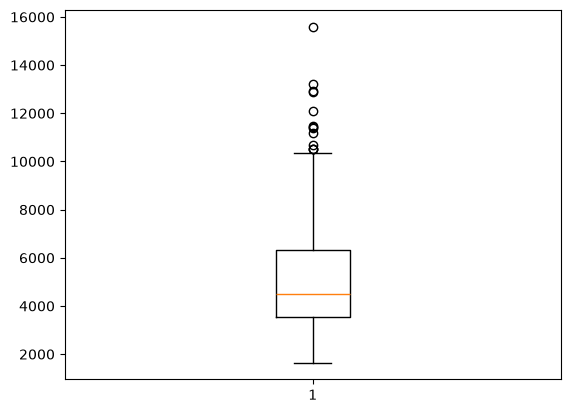

In [148]:
# area outlier treatment
plt.boxplot(housing.area)

Q1 = housing.area.quantile(0.25)
Q3 = housing.area.quantile(0.75)

iqr = Q3 - Q1

housing = housing[(housing.area >= Q1 - 1.5*iqr) & (housing.area <= Q3 + 1.5*iqr)]

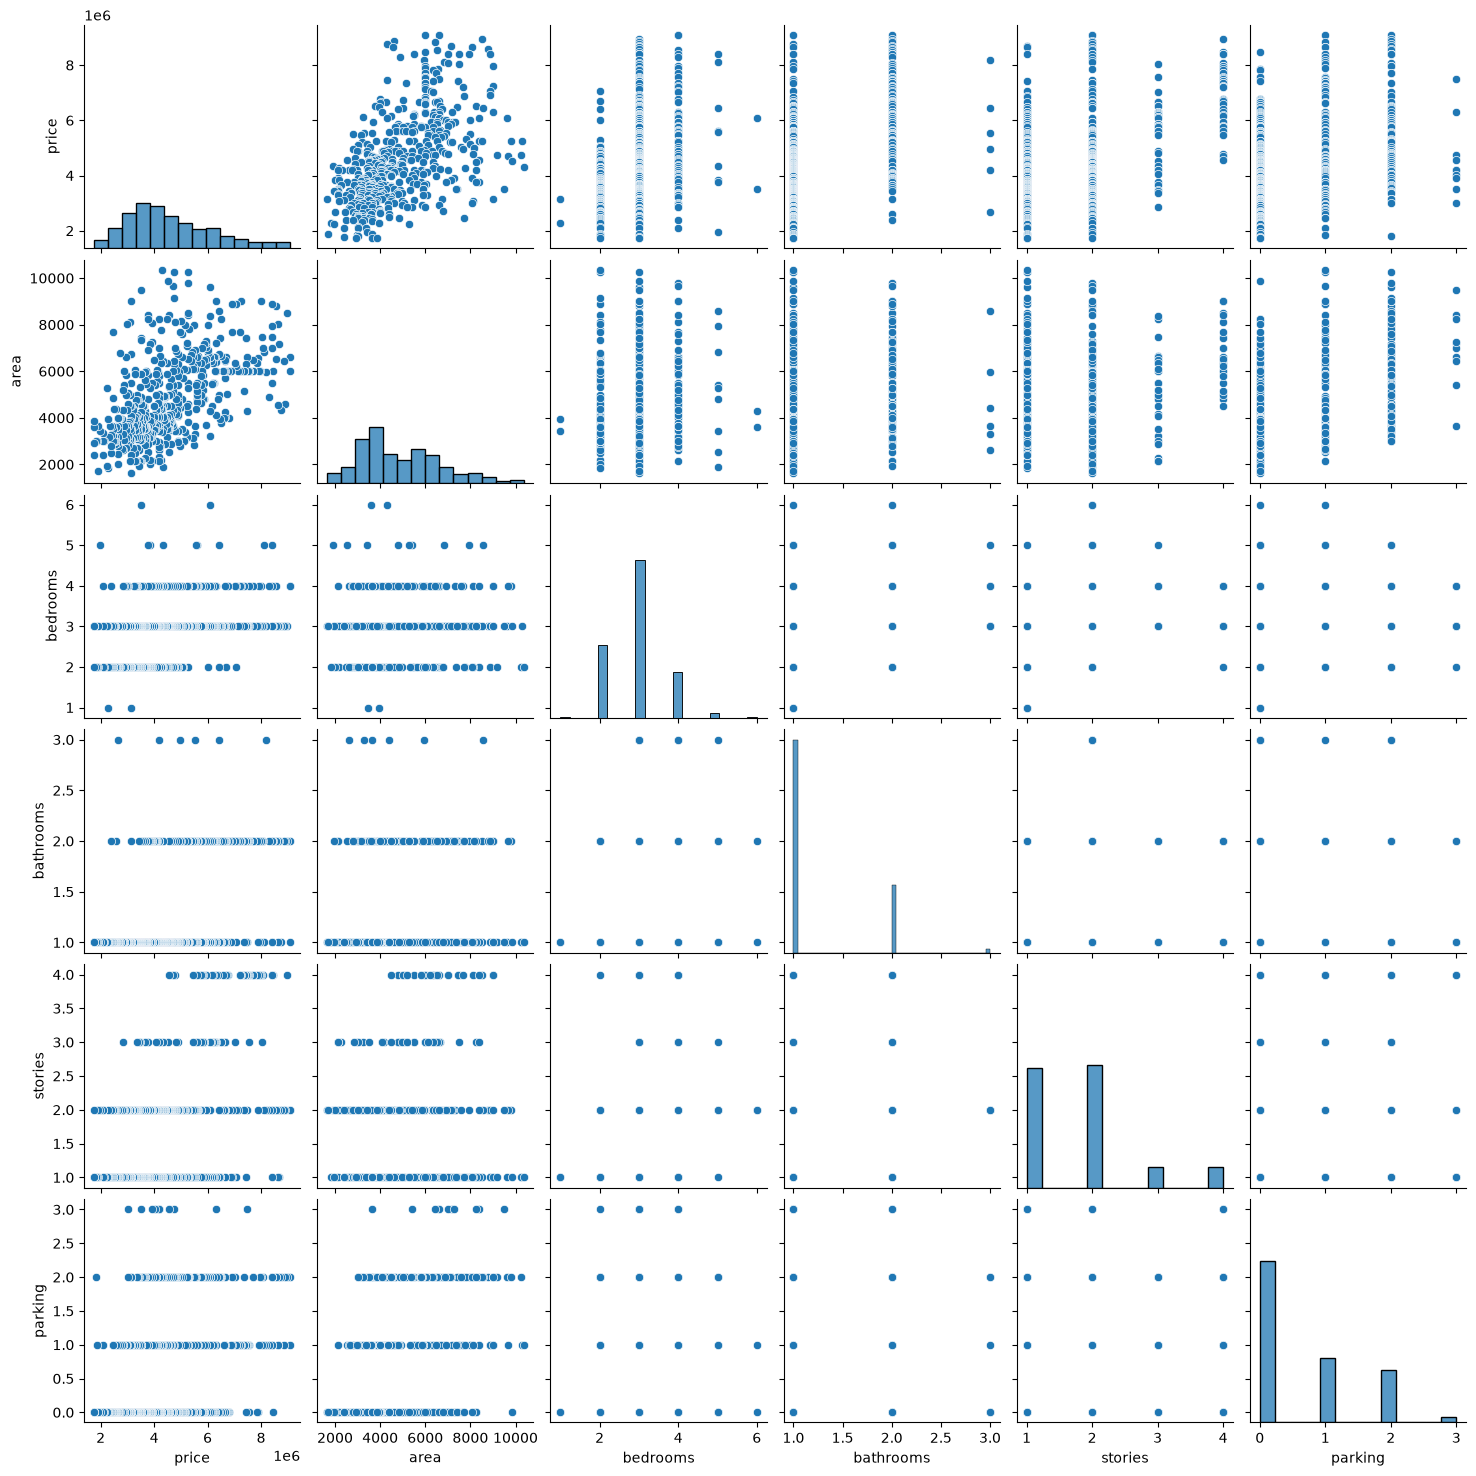

In [149]:
sns.pairplot(housing)
plt.show()

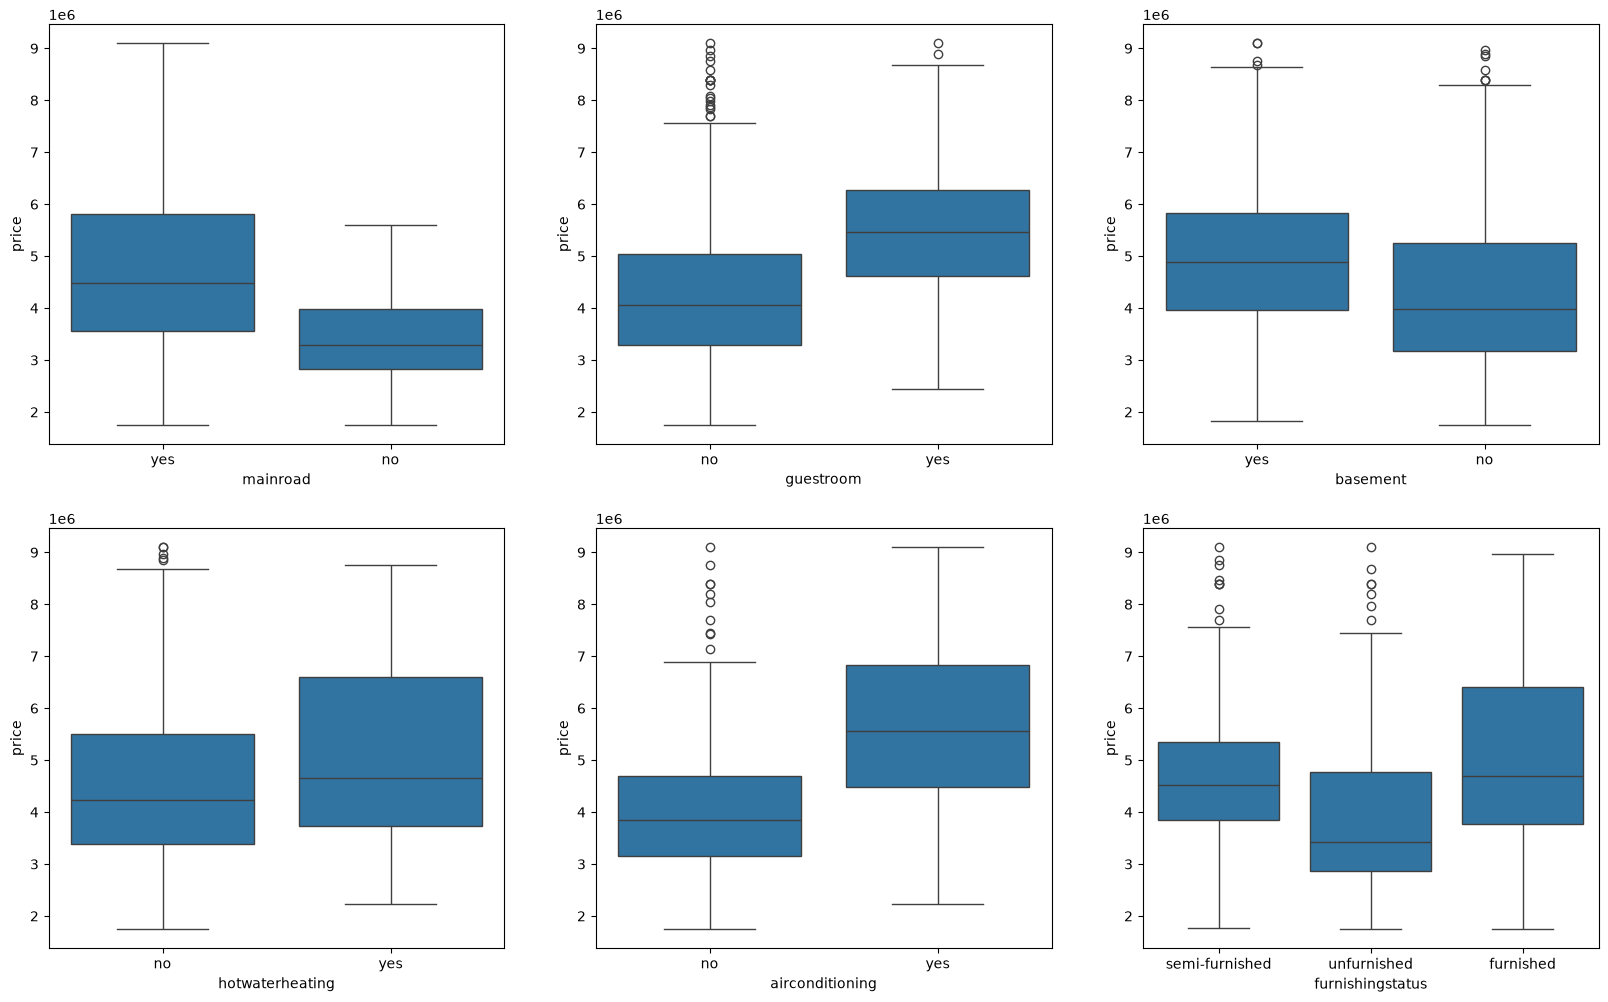

In [150]:
plt.figure(figsize=(20, 12))
plt.subplot(2,3,1)
sns.boxplot(x = 'mainroad', y = 'price', data = housing)
plt.subplot(2,3,2)
sns.boxplot(x = 'guestroom', y = 'price', data = housing)
plt.subplot(2,3,3)
sns.boxplot(x = 'basement', y = 'price', data = housing)
plt.subplot(2,3,4)
sns.boxplot(x = 'hotwaterheating', y = 'price', data = housing)
plt.subplot(2,3,5)
sns.boxplot(x = 'airconditioning', y = 'price', data = housing)
plt.subplot(2,3,6)
sns.boxplot(x = 'furnishingstatus', y = 'price', data = housing)
plt.show()

In [151]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler

In [152]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(housing.iloc[:,1:],housing.iloc[:,0], test_size=0.3, random_state=0)

In [153]:
X_train.shape , y_train.shape

((361, 12), (361,))

In [154]:
from sklearn.compose import ColumnTransformer
transformer = ColumnTransformer(transformers=[
    ('encode1',OneHotEncoder(sparse_output=False,drop='first'),['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']),
    ('encode2',OrdinalEncoder(categories=[['unfurnished','semi-furnished','furnished']]),['furnishingstatus']),
    ('scale',MinMaxScaler(), ['area','bedrooms','bathrooms','stories','parking'])
],remainder='passthrough')

In [155]:
X_train_transformed = transformer.fit_transform(X_train)
feature_names = transformer.get_feature_names_out()
X_train_transformed = pd.DataFrame(
    X_train_transformed,
    columns=feature_names
)

In [156]:
X_train_transformed.shape

(361, 12)

In [157]:
X_train_transformed.head()

,encode1__mainroad_yes,encode1__guestroom_yes,encode1__basement_yes,encode1__hotwaterheating_yes,encode1__airconditioning_yes,encode1__prefarea_yes,encode2__furnishingstatus,scale__area,scale__bedrooms,scale__bathrooms,scale__stories,scale__parking
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.210060,0.6,0.0,0.333333,0.666667
1,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.305753,0.4,0.0,0.333333,0.666667
2,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.554324,0.4,0.5,0.000000,0.000000
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.072937,0.4,0.0,0.333333,0.000000
4,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.169215,0.4,0.5,0.000000,0.000000


In [158]:
X_test_transformed = transformer.fit_transform(X_test)
feature_names = transformer.get_feature_names_out()
X_test_transformed = pd.DataFrame(
    X_test_transformed,
    columns=feature_names
)

In [159]:
X_test_transformed.head()

,encode1__mainroad_yes,encode1__guestroom_yes,encode1__basement_yes,encode1__hotwaterheating_yes,encode1__airconditioning_yes,encode1__prefarea_yes,encode2__furnishingstatus,scale__area,scale__bedrooms,scale__bathrooms,scale__stories,scale__parking
0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.251435,0.50,0.0,0.333333,0.333333
1,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.165327,0.25,0.0,0.000000,0.000000
2,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.301952,0.25,0.0,0.000000,0.666667
3,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0.757750,0.50,0.0,0.000000,0.000000
4,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.132032,0.50,0.5,0.333333,0.333333


In [160]:
X_train_transformed.shape

(361, 12)

In [161]:
y_train.shape

(361,)

# Model Training and visualizing performance metrics

In [162]:
from sklearn.linear_model import LinearRegression

In [163]:
lm = LinearRegression()
lm.fit(X_train_transformed, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[ 434673.6 , 114683.52, 475317.11,...,1348955.65,1681238.02, 639973.49]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](12,)","['encode1__mainroad_yes','encode1__guestroom_yes','encode1__basement_yes', ...,'scale__bathrooms','scale__stories','scale__parking']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.869e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,12


In [164]:
y_train_price = lm.predict(X_train_transformed)

In [165]:
res = (y_train_price - y_train)

In [166]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Text(0.5, 0, 'Errors')

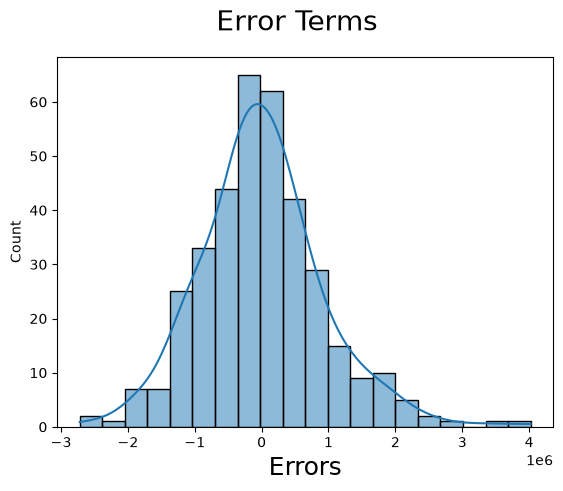

In [167]:
fig = plt.figure()
sns.histplot((y_train - y_train_price), bins = 20, kde = True)
fig.suptitle('Error Terms', fontsize = 20)     
plt.xlabel('Errors', fontsize = 18)    

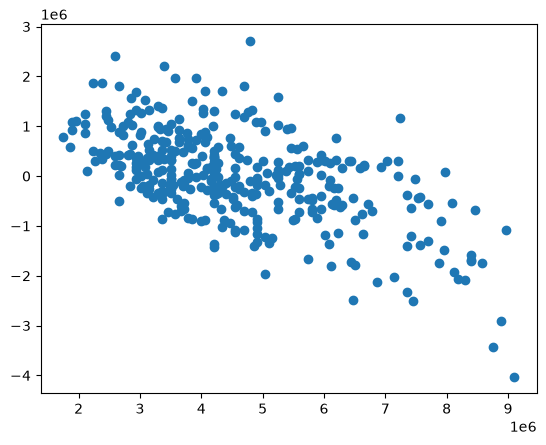

In [168]:
plt.scatter(y_train,res)
plt.show()

In [169]:
y_pred = lm.predict(X_test_transformed)

In [170]:
from sklearn.metrics import r2_score 
r2_score(y_test, y_pred)

0.6556447177922389

Text(0, 0.5, 'y_pred')

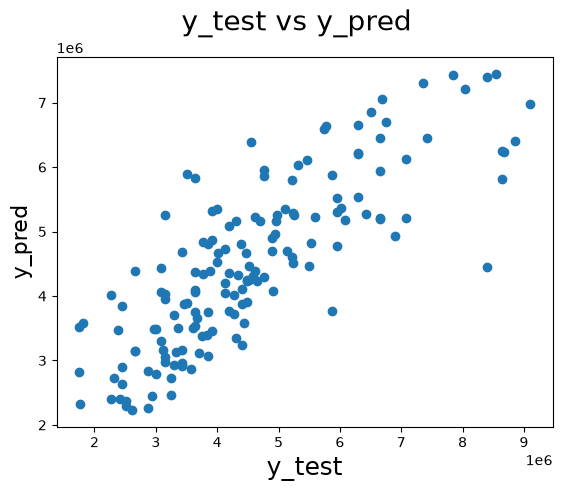

In [171]:
fig = plt.figure()
plt.scatter(y_test,y_pred)
fig.suptitle('y_test vs y_pred', fontsize=20)               
plt.xlabel('y_test', fontsize=18)                          
plt.ylabel('y_pred', fontsize=16)   